In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# === FIX PATH BASED ON NOTEBOOK LOCATION ===
notebook_dir = os.getcwd()
print("Current notebook directory:", notebook_dir)

# Try different possible paths
data_paths = [
    'data/BrentOilPrices.csv',           # if notebook in root
    '../data/BrentOilPrices.csv',        # if notebook in notebooks/
    '../../data/BrentOilPrices.csv'
]

df = None
for path in data_paths:
    try:
        df = pd.read_csv(path)
        print(f"✅ SUCCESS: Loaded from {path}")
        break
    except FileNotFoundError:
        print(f"  Tried {path} - not found")

if df is None:
    raise FileNotFoundError("CSV file not found. Please check your folder structure.")

# === ROBUST DATE PARSING ===
def parse_brent_date(date_str):
    date_str = str(date_str).strip().strip('"').strip("'")
    for fmt in ['%d-%b-%y', '%b %d, %Y', '%Y-%m-%d']:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT

df['Date'] = df['Date'].apply(parse_brent_date)
df = df.dropna(subset=['Date']).reset_index(drop=True)
df = df.sort_values('Date').reset_index(drop=True)

print("\n✅ Data loaded and cleaned successfully!")
print("Date range:", df['Date'].min().date(), "→", df['Date'].max().date())
print("Total rows:", len(df))
print(df.head())

Current notebook directory: c:\Users\user 1\Desktop\brent-oil-change-point-analysis\notebooks
  Tried data/BrentOilPrices.csv - not found
✅ SUCCESS: Loaded from ../data/BrentOilPrices.csv

✅ Data loaded and cleaned successfully!
Date range: 1987-05-20 → 2022-11-14
Total rows: 9011
        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63


✅ Figures folder ready at: c:\Users\user 1\Desktop\brent-oil-change-point-analysis\figures


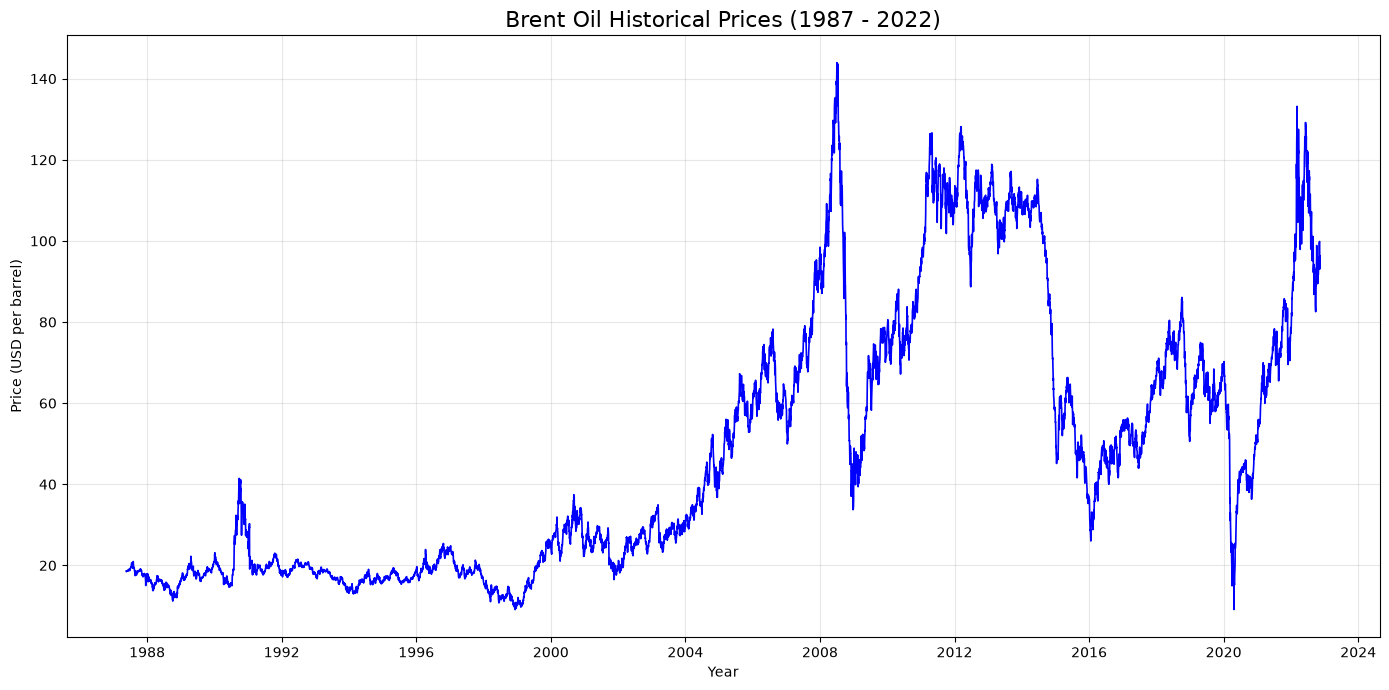

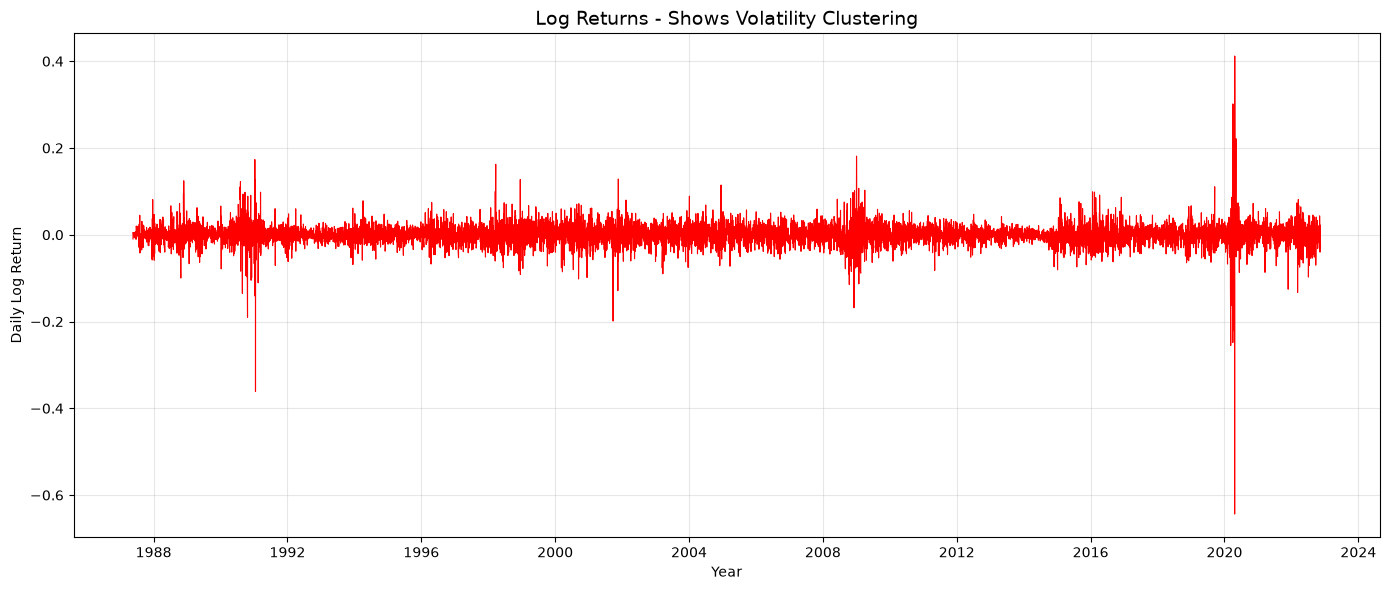

=== ADF Stationarity Test (Raw Prices) ===
ADF Statistic:      -1.9939
p-value:            0.289274
Critical Values:    {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}

Conclusion: Raw prices are NON-stationary (as expected)


In [9]:
import os

# Create figures folder correctly from notebooks/ directory
os.makedirs('../figures', exist_ok=True)
print("✅ Figures folder ready at:", os.path.abspath('../figures'))

# 1. Price Trend Plot
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Price'], linewidth=1.2, color='blue')
plt.title('Brent Oil Historical Prices (1987 - 2022)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD per barrel)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/brent_prices_full.png', dpi=300)
plt.show()

# 2. Log Returns
df['LogReturn'] = np.log(df['Price'] / df['Price'].shift(1))

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['LogReturn'], linewidth=0.8, color='red')
plt.title('Log Returns - Shows Volatility Clustering', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Daily Log Return')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/log_returns.png', dpi=300)
plt.show()

# 3. Stationarity Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Price'].dropna())
print('=== ADF Stationarity Test (Raw Prices) ===')
print('ADF Statistic:     ', round(result[0], 4))
print('p-value:           ', round(result[1], 6))
print('Critical Values:   ', result[4])
print('\nConclusion: Raw prices are NON-stationary (as expected)')